# Notebook 1 — EDA & Preprocessing
## BRFSS 2022 Heart Disease Prediction

**Output:** `brfss2022_clean.csv` —clean dataset, ready for Notebook 2 EDA

### Features (17 Group)

| Group | Column |  |
|---|---|---|
| **Target** | `_MICHD` | CVD/MI — 1 = Yes, 2 = No |
| **Demographics** | `SEXVAR`, `_AGE_G` | Gender, Group Age |
| **Lifestyle** | `EXERANY2`, `_RFBMI5`, `_SMOKER3`, `DRNKANY6`, `SLEPTIM1` | Exercise, BMI, Smoking, Alcohol, Sleep |
| **Clinical** | `CHCKDNY2`, `DIABETE4`, `HAVARTH4`, `ADDEPEV3`, `CVDSTRK3`, `CHCSCNC1`, `CHCCOPD3` | Kidney, Diabetes, Arthritis, Depression, Stroke, Cancer, COPD |
| **General Health** | `GENHLTH`, `PHYSHLTH`, `MENTHLTH` | General health, Physical, Mental |
| **Socioeconomic** | `_EDUCAG`, `EMPLOY1`, `_IMPRACE` | Education, Employment, Ethnicity |


## 1.  Import

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from google.colab import files

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
OUT  = '/content/nb1_outputs'
import os; os.makedirs(OUT, exist_ok=True)
print('✓ Libraries loaded')


✓ Libraries loaded


## 2. Upload & Load raw CSV

In [ ]:
uploaded = files.upload()
RAW_PATH = list(uploaded.keys())[0]

TARGET = '_MICHD'
FEATURE_COLS = [
    # Demographics
    'SEXVAR', '_AGE_G',
    # Lifestyle
    'EXERANY2', '_RFBMI5', '_SMOKER3', 'DRNKANY6', 'SLEPTIM1',
    # Clinical
    'CHCKDNY2', 'DIABETE4', 'HAVARTH4', 'ADDEPEV3',
    'CVDSTRK3', 'CHCSCNC1', 'CHCCOPD3',
    # General Health
    'GENHLTH', 'PHYSHLTH', 'MENTHLTH',
    # Socioeconomic
    '_EDUCAG', 'EMPLOY1', '_IMPRACE',
]
ALL_COLS = [TARGET] + FEATURE_COLS

df_raw = pd.read_csv(RAW_PATH, usecols=ALL_COLS, low_memory=False)
for c in ALL_COLS:
    df_raw[c] = pd.to_numeric(df_raw[c], errors='coerce')

print(f'Raw shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()


Saving brfss2022.csv to brfss2022.csv
Raw shape: (445132, 21)
Columns: ['SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'EXERANY2', 'SLEPTIM1', 'CVDSTRK3', 'CHCSCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'EMPLOY1', '_IMPRACE', '_MICHD', '_AGE_G', '_RFBMI5', '_EDUCAG', '_SMOKER3', 'DRNKANY6']


,SEXVAR,GENHLTH,PHYSHLTH,MENTHLTH,EXERANY2,SLEPTIM1,CVDSTRK3,CHCSCNC1,CHCCOPD3,ADDEPEV3,CHCKDNY2,HAVARTH4,DIABETE4,EMPLOY1,_IMPRACE,_MICHD,_AGE_G,_RFBMI5,_EDUCAG,_SMOKER3,DRNKANY6
0,2.0000,2.0000,88.0000,88.0000,2.0000,8.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,1.0000,7.0000,1.0000,2.0000,6.0000,9.0000,4.0000,4.0000,2.0000
1,2.0000,1.0000,88.0000,88.0000,2.0000,6.0000,2.0000,1.0000,2.0000,2.0000,2.0000,2.0000,3.0000,2.0000,1.0000,2.0000,6.0000,2.0000,2.0000,4.0000,2.0000
2,2.0000,2.0000,2.0000,3.0000,1.0000,5.0000,2.0000,1.0000,2.0000,2.0000,2.0000,2.0000,3.0000,7.0000,1.0000,2.0000,5.0000,2.0000,4.0000,4.0000,2.0000
3,2.0000,1.0000,88.0000,88.0000,1.0000,7.0000,2.0000,2.0000,2.0000,2.0000,2.0000,1.0000,3.0000,7.0000,1.0000,2.0000,6.0000,1.0000,2.0000,2.0000,2.0000
4,2.0000,4.0000,2.0000,88.0000,1.0000,9.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,3.0000,5.0000,1.0000,2.0000,3.0000,1.0000,3.0000,4.0000,1.0000


## 3. Check target & Class distribution

Total valid: 440,111
CVD/MI (1) : 39,751  (9.03%)
No CVD (2) : 400,360  (90.97%)
Imbalance  : 10.1:1


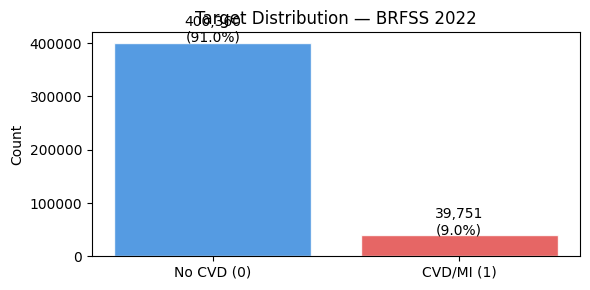

In [ ]:
# Only keep valid targets
df = df_raw[df_raw[TARGET].isin([1, 2])].copy()
pos = (df[TARGET]==1).sum()
neg = (df[TARGET]==2).sum()
total = len(df)

print(f'Total valid: {total:,}')
print(f'CVD/MI (1) : {pos:,}  ({pos/total*100:.2f}%)')
print(f'No CVD (2) : {neg:,}  ({neg/total*100:.2f}%)')
print(f'Imbalance  : {neg/pos:.1f}:1')

# Plot
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(['No CVD (0)', 'CVD/MI (1)'], [neg, pos],
       color=['#378ADD', '#E24B4A'], alpha=0.85, edgecolor='white')
ax.set_title('Target Distribution — BRFSS 2022')
ax.set_ylabel('Count')
for bar, val in zip(ax.patches, [neg, pos]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
            f'{val:,}\n({val/total*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
fig.savefig(f'{OUT}/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Missing value analysis

Missing % sau replace invalid codes:
_RFBMI5    10.8732
DRNKANY6   10.3881
_SMOKER3    7.9007
EMPLOY1     2.4719
PHYSHLTH    2.3728
MENTHLTH    1.9736
SLEPTIM1    1.1618
CHCSCNC1    0.6069
ADDEPEV3    0.5340
HAVARTH4    0.5085
_EDUCAG     0.4912
CHCCOPD3    0.3969
CHCKDNY2    0.3456
GENHLTH     0.2415
CVDSTRK3    0.2329
EXERANY2    0.2184
DIABETE4    0.1763

PHYSHLTH=88 (zero days): 265,688 records → giữ lại đúng
MENTHLTH=88 (zero days): 262,486 records → giữ lại đúng


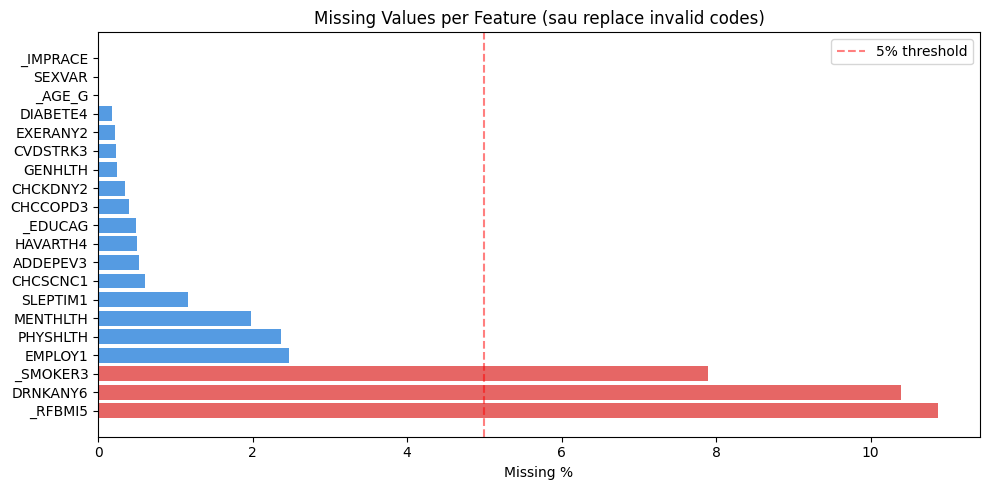

In [ ]:
# Invalid codes theo BRFSS 2022 codebook
INVALID = {
    '_MICHD'  : [7, 9],
    'SEXVAR'  : [7, 9],
    '_AGE_G'  : [7, 9],
    'EXERANY2': [7, 9],
    '_RFBMI5' : [9],
    '_SMOKER3': [9],
    'DRNKANY6': [7, 9],
    'SLEPTIM1': [77, 99],
    'CHCKDNY2': [7, 9],
    'DIABETE4': [7, 9],
    'HAVARTH4': [7, 9],
    'ADDEPEV3': [7, 9],
    'CVDSTRK3': [7, 9],
    'CHCSCNC1': [7, 9],
    'CHCCOPD3': [7, 9],
    'GENHLTH' : [7, 9],
    # FIX: 88 = "None/Zero days" → KHÔNG replace, chỉ bỏ 77/99
    'PHYSHLTH': [77, 99],
    'MENTHLTH': [77, 99],
    '_EDUCAG' : [9],
    'EMPLOY1' : [9],
    '_IMPRACE': [7, 9],
}

for col, codes in INVALID.items():
    df[col] = df[col].replace(codes, np.nan)

# FIX: 88 = None/Zero days → đổi thành 0 (không bị ốm ngày nào)
df['PHYSHLTH'] = df['PHYSHLTH'].replace(88, 0)
df['MENTHLTH'] = df['MENTHLTH'].replace(88, 0)

# Missing % sau replace
miss = (df[FEATURE_COLS].isna().mean() * 100).sort_values(ascending=False)
print('Missing % sau replace invalid codes:')
print(miss[miss > 0].to_string())
print(f'\nPHYSHLTH=88 (zero days): {(df["PHYSHLTH"]==0).sum():,} records → giữ lại đúng')
print(f'MENTHLTH=88 (zero days): {(df["MENTHLTH"]==0).sum():,} records → giữ lại đúng')

# Plot missing
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E24B4A' if v > 5 else '#378ADD' if v > 0 else '#1D9E75'
          for v in miss.values]
ax.barh(miss.index, miss.values, color=colors, alpha=0.85)
ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Feature (sau replace invalid codes)')
ax.legend()
plt.tight_layout()
fig.savefig(f'{OUT}/02_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. EDA — Analyzing each feature with the target

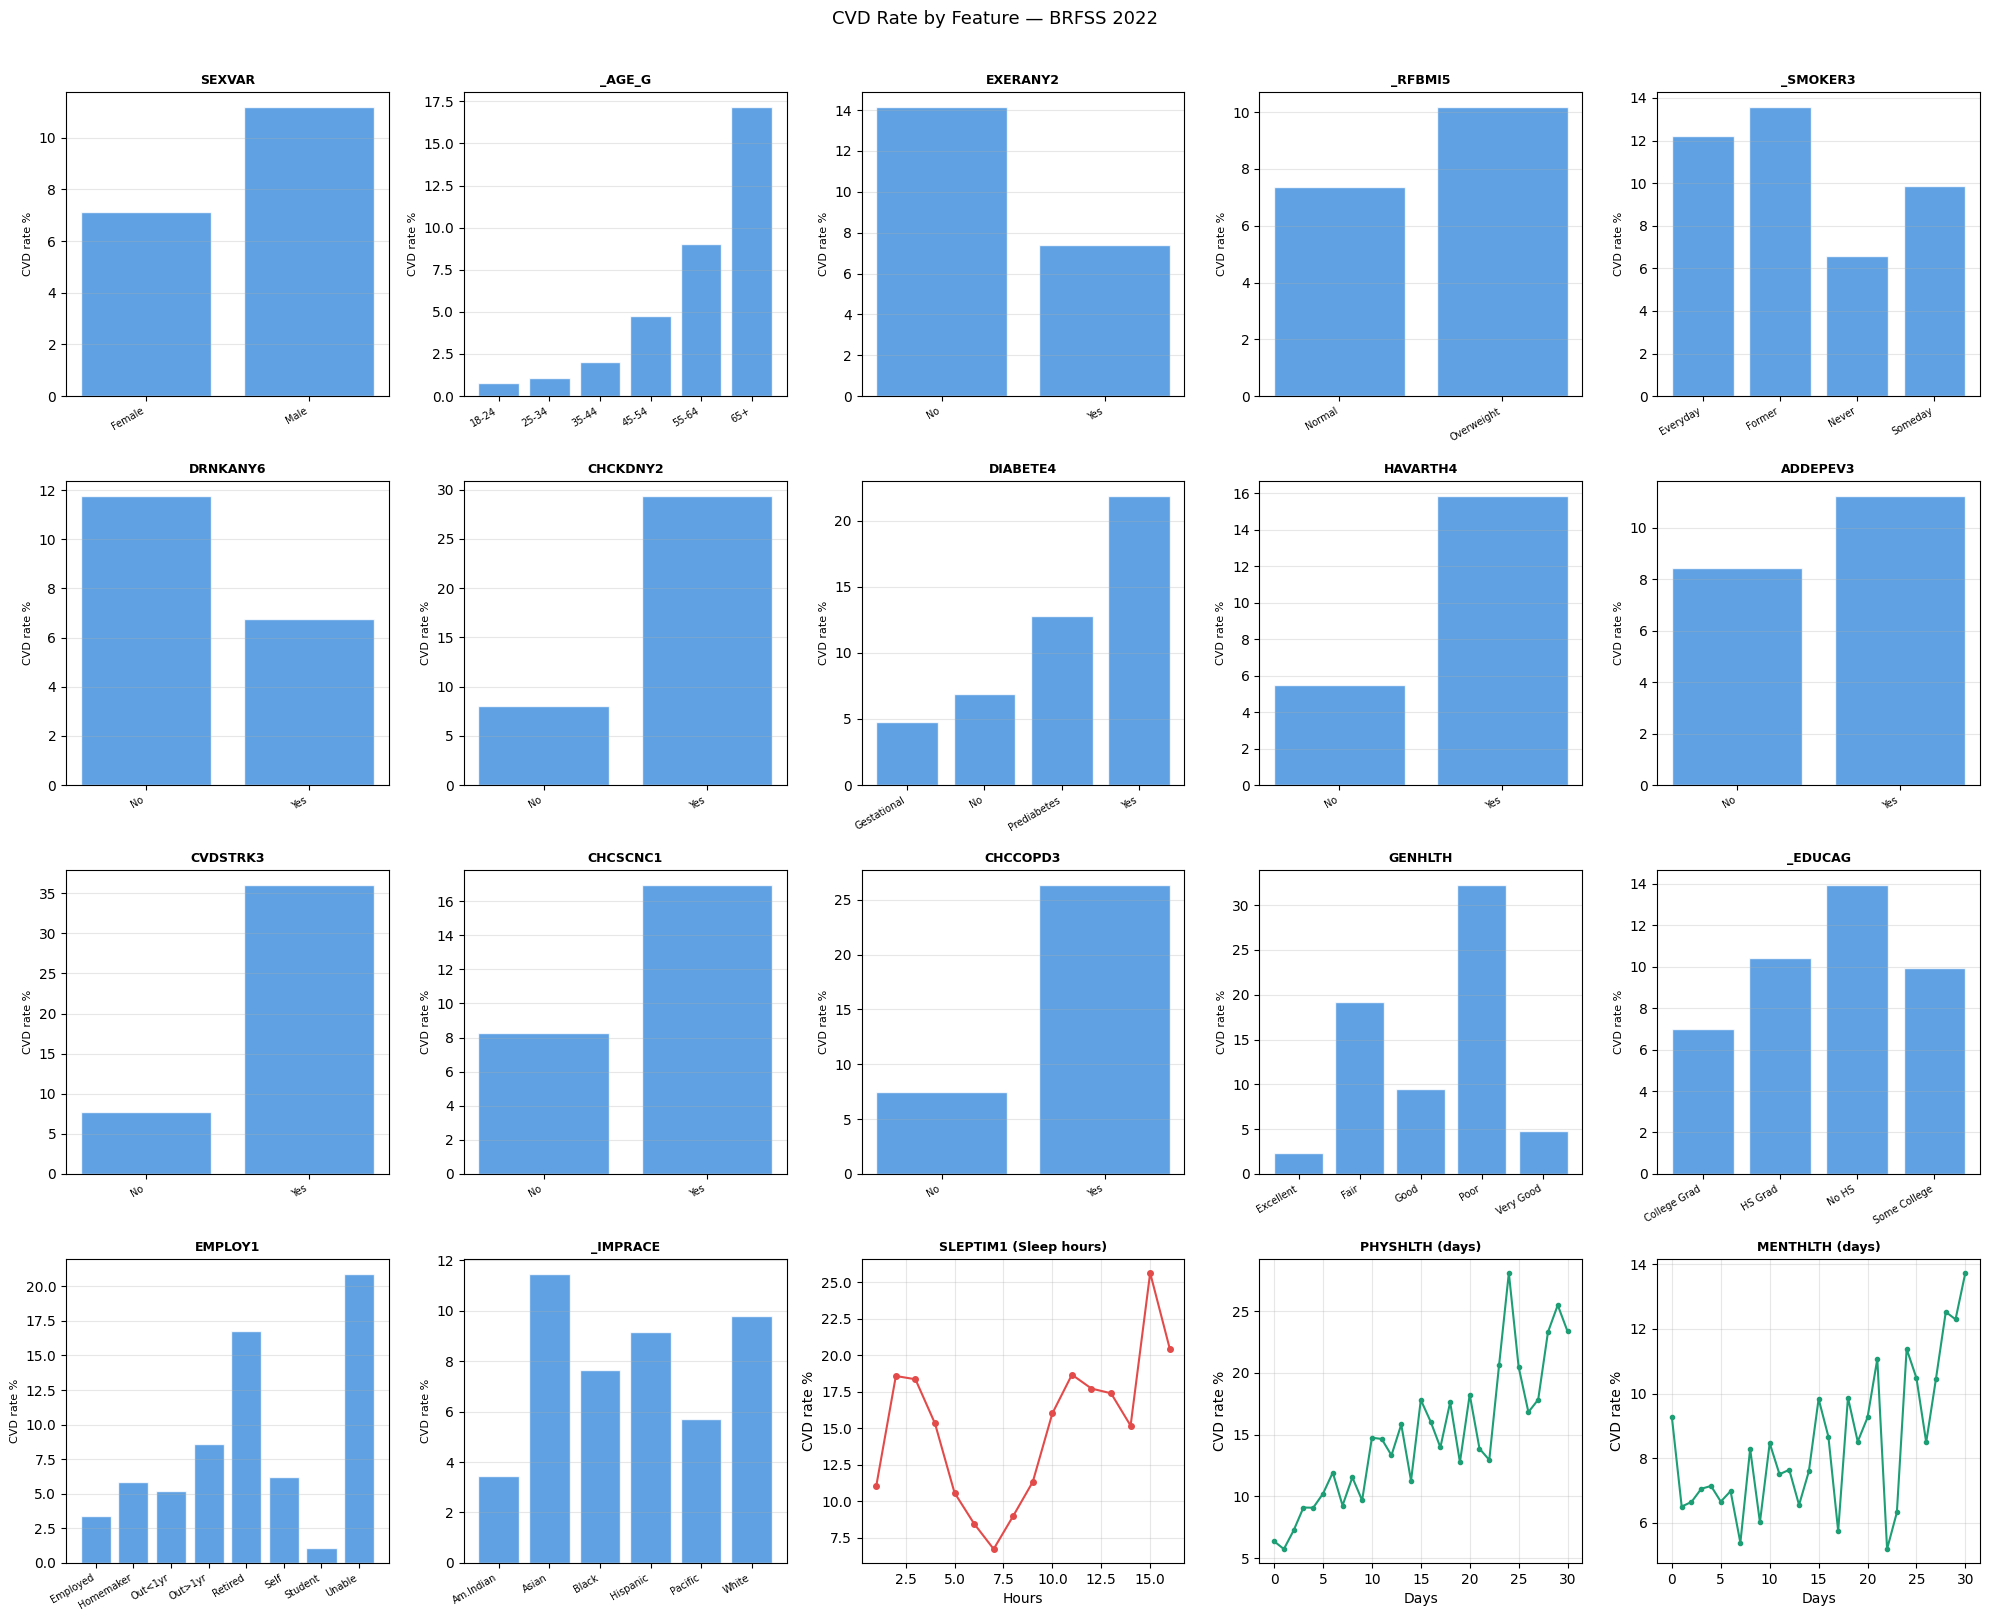

In [ ]:
# CVD rate theo từng feature
df_eda = df.copy()
df_eda['CVD'] = (df_eda[TARGET] == 1).astype(int)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

cat_features = {
    'SEXVAR'  : {1:'Male', 2:'Female'},
    '_AGE_G'  : {1:'18-24',2:'25-34',3:'35-44',4:'45-54',5:'55-64',6:'65+'},
    'EXERANY2': {1:'Yes', 2:'No'},
    '_RFBMI5' : {1:'Normal', 2:'Overweight'},
    '_SMOKER3': {1:'Everyday',2:'Someday',3:'Former',4:'Never'},
    'DRNKANY6': {1:'Yes', 2:'No'},
    'CHCKDNY2': {1:'Yes', 2:'No'},
    'DIABETE4': {1:'Yes',2:'Gestational',3:'No',4:'Prediabetes'},
    'HAVARTH4': {1:'Yes', 2:'No'},
    'ADDEPEV3': {1:'Yes', 2:'No'},
    'CVDSTRK3': {1:'Yes', 2:'No'},
    'CHCSCNC1': {1:'Yes', 2:'No'},
    'CHCCOPD3': {1:'Yes', 2:'No'},
    'GENHLTH' : {1:'Excellent',2:'Very Good',3:'Good',4:'Fair',5:'Poor'},
    '_EDUCAG' : {1:'No HS',2:'HS Grad',3:'Some College',4:'College Grad'},
    'EMPLOY1' : {1:'Employed',2:'Self',3:'Out>1yr',4:'Out<1yr',5:'Homemaker',6:'Student',7:'Retired',8:'Unable'},
    '_IMPRACE': {1:'White',2:'Black',3:'Am.Indian',4:'Asian',5:'Pacific',6:'Hispanic'},
}

for i, (col, label_map) in enumerate(cat_features.items()):
    ax = axes[i]
    temp = df_eda[[col,'CVD']].dropna()
    if label_map:
        temp[col] = temp[col].map(label_map)
    cvd_rate = temp.groupby(col)['CVD'].mean() * 100
    bars = ax.bar(range(len(cvd_rate)), cvd_rate.values,
                  color='#378ADD', alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(cvd_rate)))
    ax.set_xticklabels(cvd_rate.index, rotation=30, ha='right', fontsize=7)
    ax.set_title(f'{col}', fontsize=9, fontweight='bold')
    ax.set_ylabel('CVD rate %', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Sleep continuous
ax = axes[len(cat_features)]
sleep_data = df_eda[['SLEPTIM1','CVD']].dropna()
cvd_sleep = sleep_data.groupby(sleep_data['SLEPTIM1'].clip(0,16))['CVD'].mean()*100
ax.plot(cvd_sleep.index, cvd_sleep.values, marker='o', ms=4, color='#E24B4A')
ax.set_title('SLEPTIM1 (Sleep hours)', fontsize=9, fontweight='bold')
ax.set_xlabel('Hours'); ax.set_ylabel('CVD rate %')
ax.grid(alpha=0.3)

# PHYSHLTH & MENTHLTH
for j, col in enumerate(['PHYSHLTH','MENTHLTH']):
    ax = axes[len(cat_features)+1+j]
    temp = df_eda[[col,'CVD']].dropna()
    grp = temp.groupby(temp[col].clip(0,30))['CVD'].mean()*100
    ax.plot(grp.index, grp.values, marker='o', ms=3, color='#1D9E75')
    ax.set_title(f'{col} (days)', fontsize=9, fontweight='bold')
    ax.set_xlabel('Days'); ax.set_ylabel('CVD rate %')
    ax.grid(alpha=0.3)

for ax in axes[len(cat_features)+3:]:
    ax.set_visible(False)

plt.suptitle('CVD Rate by Feature — BRFSS 2022', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT}/03_eda_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Handling missing & Decision to dropna

In [ ]:
rows_before = len(df)
df_clean = df.dropna(subset=ALL_COLS).copy()
rows_after = len(df_clean)

print(f'Rows befor dropna: {rows_before:,}')
print(f'Rows after dropna  : {rows_after:,}')
print(f'Rows are removed     : {rows_before-rows_after:,} ({(rows_before-rows_after)/rows_before*100:.1f}%)')

pos2 = (df_clean[TARGET]==1).sum()
print(f'\nCVD rate after dropna: {pos2/rows_after*100:.2f}%')
print(f'Imbalance: {(rows_after-pos2)/pos2:.1f}:1')

# Kiểm tra missing còn lại
assert df_clean.isna().sum().sum() == 0, 'Still missing!'
print('\n✓ No more missing values')


Rows trước dropna: 440,111
Rows sau dropna  : 340,154
Rows bị loại     : 99,957 (22.7%)

CVD rate sau dropna: 8.89%
Imbalance: 10.2:1

✓ Không còn missing value


## 7. Recode — Split into binary columns

In [ ]:
dm = pd.DataFrame(index=df_clean.index)

# ── Target ──────────────────────────────────────────────────────────────────
dm['target'] = (df_clean[TARGET] == 1).astype(np.int8)

# ── Demographics ─────────────────────────────────────────────────────────────
dm['Male']        = (df_clean['SEXVAR'] == 1).astype(np.int8)
for v,l in zip(range(1,7),['18_24','25_34','35_44','45_54','55_64','65_plus']):
    dm[f'Age_{l}'] = (df_clean['_AGE_G'] == v).astype(np.int8)

# ── Lifestyle ─────────────────────────────────────────────────────────────────
dm['Sleep_hours']       = df_clean['SLEPTIM1'].astype(np.float32)
dm['Physical_activity'] = (df_clean['EXERANY2'] == 1).astype(np.int8)
dm['Overweight_obese']  = (df_clean['_RFBMI5']  == 2).astype(np.int8)
dm['Alcohol']           = (df_clean['DRNKANY6'] == 1).astype(np.int8)
for v,l in zip(range(1,5),['everyday','someday','former','never']):
    dm[f'Smoking_{l}'] = (df_clean['_SMOKER3'] == v).astype(np.int8)

# ── Clinical ──────────────────────────────────────────────────────────────────
dm['Kidney_disease']    = (df_clean['CHCKDNY2'] == 1).astype(np.int8)
dm['Diabetes_yes']      = (df_clean['DIABETE4'] == 1).astype(np.int8)
dm['Diabetes_gest']     = (df_clean['DIABETE4'] == 2).astype(np.int8)
dm['Diabetes_no']       = (df_clean['DIABETE4'] == 3).astype(np.int8)
dm['Diabetes_pre']      = (df_clean['DIABETE4'] == 4).astype(np.int8)
dm['Arthritis']         = (df_clean['HAVARTH4'] == 1).astype(np.int8)
dm['Depression']        = (df_clean['ADDEPEV3'] == 1).astype(np.int8)
dm['Stroke']            = (df_clean['CVDSTRK3'] == 1).astype(np.int8)
dm['Cancer']            = (df_clean['CHCSCNC1'] == 1).astype(np.int8)
dm['COPD']              = (df_clean['CHCCOPD3'] == 1).astype(np.int8)

# ── General Health ────────────────────────────────────────────────────────────
# GENHLTH: 1=Excellent, 2=Very Good, 3=Good, 4=Fair, 5=Poor
for v,l in zip(range(1,6),['excellent','very_good','good','fair','poor']):
    dm[f'GenHealth_{l}'] = (df_clean['GENHLTH'] == v).astype(np.int8)
# PHYSHLTH/MENTHLTH: số ngày không khỏe trong 30 ngày (0-30, 88=None)
# CŨ — SAI (88 đã bị replace thành NaN từ trước)
dm['PhysHealth_days'] = df_clean['PHYSHLTH'].clip(0,30).astype(np.float32)
dm['MentHealth_days'] = df_clean['MENTHLTH'].clip(0,30).astype(np.float32)

# ── Socioeconomic ─────────────────────────────────────────────────────────────
for v,l in zip(range(1,5),['no_hs','hs_grad','some_college','college_grad']):
    dm[f'Edu_{l}'] = (df_clean['_EDUCAG'] == v).astype(np.int8)
for v,l in zip(range(1,9),['employed','self','out_1yr','out_less1yr',
                             'homemaker','student','retired','unable']):
    dm[f'Emp_{l}'] = (df_clean['EMPLOY1'] == v).astype(np.int8)
for v,l in zip(range(1,7),['white','black','am_indian','asian','pacific','hispanic']):
    dm[f'Race_{l}'] = (df_clean['_IMPRACE'] == v).astype(np.int8)

print(f'✓ Shape sau recode: {dm.shape}')
print(f'  Features: {dm.shape[1]-1} cột')
print(f'  Target distribution:')
print(dm['target'].value_counts().to_dict())
dm.head()


✓ Shape sau recode: (340154, 51)
  Features: 50 cột
  Target distribution:
{0: 309899, 1: 30255}


,target,Male,Age_18_24,Age_25_34,Age_35_44,Age_45_54,Age_55_64,Age_65_plus,Sleep_hours,Physical_activity,Overweight_obese,Alcohol,Smoking_everyday,Smoking_someday,Smoking_former,Smoking_never,Kidney_disease,Diabetes_yes,Diabetes_gest,Diabetes_no,Diabetes_pre,Arthritis,Depression,Stroke,Cancer,...,GenHealth_excellent,GenHealth_very_good,GenHealth_good,GenHealth_fair,GenHealth_poor,PhysHealth_days,MentHealth_days,Edu_no_hs,Edu_hs_grad,Edu_some_college,Edu_college_grad,Emp_employed,Emp_self,Emp_out_1yr,Emp_out_less1yr,Emp_homemaker,Emp_student,Emp_retired,Emp_unable,Race_white,Race_black,Race_am_indian,Race_asian,Race_pacific,Race_hispanic
1,0,0,0,0,0,0,0,1,6.0000,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,...,1,0,0,0,0,0.0000,0.0000,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,1,0,5.0000,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,...,0,1,0,0,0,2.0000,3.0000,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,1,7.0000,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,...,1,0,0,0,0,0.0000,0.0000,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
4,0,0,0,0,1,0,0,0,9.0000,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,2.0000,0.0000,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
5,1,1,0,0,0,0,0,1,7.0000,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,...,0,0,0,0,1,1.0000,0.0000,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0


## 8. Final check & Saved CSV

In [ ]:
# last check
assert dm.isna().sum().sum() == 0, 'Còn missing!'
assert 'target' in dm.columns

feat_cols = [c for c in dm.columns if c != 'target']
pos_final = dm['target'].sum()
total_final = len(dm)

print('='*50)
print('SUMMARY — Notebook 1')
print('='*50)
print(f'Total records : {total_final:,}')
print(f'Features      : {len(feat_cols)} cột')
print(f'CVD positive  : {pos_final:,} ({pos_final/total_final*100:.2f}%)')
print(f'No CVD        : {total_final-pos_final:,} ({(total_final-pos_final)/total_final*100:.2f}%)')
print(f'Imbalance     : {(total_final-pos_final)/pos_final:.1f}:1')
print()
print('Feature groups:')
print(f'  Demographics : Male, Age_* (6 cols)')
print(f'  Lifestyle    : Sleep, PhysAct, BMI, Alcohol, Smoking_* (4 cols)')
print(f'  Clinical     : Kidney, Diabetes_* (4 cols), Arthritis, Depression,')
print(f'                 Stroke, Cancer, COPD')
print(f'  General Health: GenHealth_* (5 cols), PhysHealth_days, MentHealth_days')
print(f'  Socioeconomic: Edu_* (4), Emp_* (8), Race_* (6)')
print()

# save
CLEAN_PATH = '/content/brfss2022_clean.csv'
dm.to_csv(CLEAN_PATH, index=False)
print(f'✓ Saved: {CLEAN_PATH}')
print(f'  Size: {dm.memory_usage(deep=True).sum()/1e6:.1f} MB')

# Download
files.download(CLEAN_PATH)


SUMMARY — Notebook 1
Total records : 340,154
Features      : 50 cột
CVD positive  : 30,255 (8.89%)
No CVD        : 309,899 (91.11%)
Imbalance     : 10.2:1

Feature groups:
  Demographics : Male, Age_* (6 cols)
  Lifestyle    : Sleep, PhysAct, BMI, Alcohol, Smoking_* (4 cols)
  Clinical     : Kidney, Diabetes_* (4 cols), Arthritis, Depression,
                 Stroke, Cancer, COPD
  General Health: GenHealth_* (5 cols), PhysHealth_days, MentHealth_days
  Socioeconomic: Edu_* (4), Emp_* (8), Race_* (6)

✓ Saved: /content/brfss2022_clean.csv
  Size: 23.1 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>